<a href="https://colab.research.google.com/github/noel-odero/Formative-2---Data-Preprocessing/blob/main/Formative2_task1_Data_merge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Formative 2 - Task 1: Data Merge, EDA & Product Prediction Model

## Overview
In this task, we work with two datasets:
- `customer_social_profiles.xlsx` - contains each customer's social media activity, engagement scores, and review sentiment
- `customer_transactions.xlsx` - contains purchase history, product categories, amounts, and ratings

Our goal is to merge these two sources into one unified dataset, clean it up, explore it visually, engineer useful features, and train a model that predicts which **product category** a customer is likely to purchase.

In [43]:
# Imports
# Importing all libraries we'll need for this task
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

# Makes our plots look clean
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

print("All libraries loaded successfully!")

All libraries loaded successfully!


## Step 1: Loading the Datasets

We load both Excel files directly using `pd.read_excel()`. We then do a quick first look at each dataset — checking shape, column types, and the first few rows — before doing anything else. This is important because you can't clean what you haven't seen.

In [44]:
# Load both datasets
social_df = pd.read_excel('customer_social_profiles.xlsx')
transactions_df = pd.read_excel('customer_transactions.xlsx')

print(" Social Profiles ")
print(f"Shape: {social_df.shape}")
display(social_df.head())

print("\n Transactions ")
print(f"Shape: {transactions_df.shape}")
display(transactions_df.head())

 Social Profiles 
Shape: (155, 5)


,customer_id_new,social_media_platform,engagement_score,purchase_interest_score,review_sentiment
0,A178,LinkedIn,74,4.9,Positive
1,A190,Twitter,82,4.8,Neutral
2,A150,Facebook,96,1.6,Positive
3,A162,Twitter,89,2.6,Positive
4,A197,Twitter,92,2.3,Neutral



 Transactions 
Shape: (150, 6)


,customer_id_legacy,transaction_id,purchase_amount,purchase_date,product_category,customer_rating
0,151,1001,408,2024-01-01,Sports,2.3
1,192,1002,332,2024-01-02,Electronics,4.2
2,114,1003,442,2024-01-03,Electronics,2.1
3,171,1004,256,2024-01-04,Clothing,2.8
4,160,1005,64,2024-01-05,Clothing,1.3


## Step 2: Data Cleaning

Before we can merge, we need to clean both datasets individually. The key issues we're handling are:

1. **Duplicate rows** — `customer_social_profiles` has 5 duplicate rows that need to be dropped
2. **Missing values** — `customer_rating` in the transactions dataset has 10 null values; we fill these with the median to avoid losing rows
3. **Inconsistent customer IDs** — The social profiles use a string format like `A178`, while transactions use plain integers like `178`. We need to standardise these before we can join the two datasets
4. **Data types** — We'll extract month and day-of-week from `purchase_date` as numeric features for the model

In [45]:
# Clean Social Profiles

print(f"Duplicates in social_df before cleaning: {social_df.duplicated().sum()}")

# Drop duplicate rows
social_df = social_df.drop_duplicates()
print(f"Duplicates after dropping: {social_df.duplicated().sum()}")

# The customer IDs in social profiles look like 'A178'
# We strip the 'A' prefix and convert to integer so we can join with transactions
social_df['customer_id'] = social_df['customer_id_new'].str.replace('A', '').astype(int)

# Drop the old string ID column since we no longer need it
social_df = social_df.drop(columns=['customer_id_new'])

print(f"\nCleaned social_df shape: {social_df.shape}")
display(social_df.head())

Duplicates in social_df before cleaning: 5
Duplicates after dropping: 0

Cleaned social_df shape: (150, 5)


,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,customer_id
0,LinkedIn,74,4.9,Positive,178
1,Twitter,82,4.8,Neutral,190
2,Facebook,96,1.6,Positive,150
3,Twitter,89,2.6,Positive,162
4,Twitter,92,2.3,Neutral,197


In [46]:
# Clean Transactions

print(f"Null values in transactions_df:\n{transactions_df.isnull().sum()}")

# Fill the 10 missing customer_rating values with the median
# We use median instead of mean because ratings can be skewed
median_rating = transactions_df['customer_rating'].median()
transactions_df['customer_rating'] = transactions_df['customer_rating'].fillna(median_rating)
print(f"\nAfter filling nulls:\n{transactions_df.isnull().sum()}")

# Rename the ID column to match social_df so the join works
transactions_df = transactions_df.rename(columns={'customer_id_legacy': 'customer_id'})

# Extract useful time-based features from purchase_date
transactions_df['purchase_month'] = transactions_df['purchase_date'].dt.month
transactions_df['purchase_dayofweek'] = transactions_df['purchase_date'].dt.dayofweek

print(f"\nCleaned transactions_df shape: {transactions_df.shape}")
display(transactions_df.head())

Null values in transactions_df:
customer_id_legacy     0
transaction_id         0
purchase_amount        0
purchase_date          0
product_category       0
customer_rating       10
dtype: int64

After filling nulls:
customer_id_legacy    0
transaction_id        0
purchase_amount       0
purchase_date         0
product_category      0
customer_rating       0
dtype: int64

Cleaned transactions_df shape: (150, 8)


,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,purchase_month,purchase_dayofweek
0,151,1001,408,2024-01-01,Sports,2.3,1,0
1,192,1002,332,2024-01-02,Electronics,4.2,1,1
2,114,1003,442,2024-01-03,Electronics,2.1,1,2
3,171,1004,256,2024-01-04,Clothing,2.8,1,3
4,160,1005,64,2024-01-05,Clothing,1.3,1,4


## Step 3: Merging the Datasets

Now that both datasets share the same `customer_id` format, we can merge them. We use an **inner join** — meaning we only keep rows where a customer appears in both datasets. This makes sense because we need both social behaviour data and transaction data to make a prediction. Customers who only exist in one dataset don't give us a complete picture.

After merging, we validate by checking the shape and confirming there are no unexpected nulls introduced.

In [47]:
merged_df = pd.merge(social_df, transactions_df, on='customer_id', how='inner')

print(f"Merged dataset shape: {merged_df.shape}")
print(f"\nNull values after merge:\n{merged_df.isnull().sum()}")
display(merged_df.head())

Merged dataset shape: (213, 12)

Null values after merge:
social_media_platform      0
engagement_score           0
purchase_interest_score    0
review_sentiment           0
customer_id                0
transaction_id             0
purchase_amount            0
purchase_date              0
product_category           0
customer_rating            0
purchase_month             0
purchase_dayofweek         0
dtype: int64


,social_media_platform,engagement_score,purchase_interest_score,review_sentiment,customer_id,transaction_id,purchase_amount,purchase_date,product_category,customer_rating,purchase_month,purchase_dayofweek
0,Twitter,82,4.8,Neutral,190,1031,333,2024-01-31,Groceries,3.8,1,2
1,Twitter,82,4.8,Neutral,190,1140,401,2024-05-19,Sports,4.9,5,6
2,Facebook,96,1.6,Positive,150,1042,389,2024-02-11,Sports,3.0,2,6
3,Facebook,96,1.6,Positive,150,1046,177,2024-02-15,Books,3.6,2,3
4,Twitter,89,2.6,Positive,162,1079,101,2024-03-19,Books,4.2,3,1


## Step 4: Post-Merge Validation

A merge can silently introduce problems - duplicate rows from a many-to-many join, unexpected nulls from mismatched IDs, or a much smaller dataset than expected. We check for all of these here.

In [48]:
print(f"Total rows: {merged_df.shape[0]}")
print(f"Unique customers in merged dataset: {merged_df['customer_id'].nunique()}")
print(f"Duplicate rows: {merged_df.duplicated().sum()}")
print(f"\nColumn types:\n{merged_df.dtypes}")
print(f"\nSummary statistics:")
display(merged_df.describe())

Total rows: 213
Unique customers in merged dataset: 61
Duplicate rows: 0

Column types:
social_media_platform              object
engagement_score                    int64
purchase_interest_score           float64
review_sentiment                   object
customer_id                         int64
transaction_id                      int64
purchase_amount                     int64
purchase_date              datetime64[ns]
product_category                   object
customer_rating                   float64
purchase_month                      int32
purchase_dayofweek                  int32
dtype: object

Summary statistics:


,engagement_score,purchase_interest_score,customer_id,transaction_id,purchase_amount,purchase_date,customer_rating,purchase_month,purchase_dayofweek
count,213.000000,213.000000,213.000000,213.000000,213.000000,213,213.000000,213.000000,213.000000
mean,75.596244,3.093427,147.676056,1075.835681,289.807512,2024-03-15 20:03:22.816901376,3.071831,2.976526,2.863850
min,50.000000,1.000000,100.000000,1001.000000,62.000000,2024-01-01 00:00:00,1.000000,1.000000,0.000000
25%,63.000000,2.100000,117.000000,1040.000000,179.000000,2024-02-09 00:00:00,2.100000,2.000000,1.000000
50%,77.000000,3.200000,147.000000,1074.000000,282.000000,2024-03-14 00:00:00,3.200000,3.000000,3.000000
75%,89.000000,4.100000,181.000000,1115.000000,398.000000,2024-04-24 00:00:00,4.100000,4.000000,5.000000
max,99.000000,5.000000,199.000000,1150.000000,495.000000,2024-05-29 00:00:00,5.000000,5.000000,6.000000
std,15.149145,1.160211,32.325632,45.104138,119.323903,NaN,1.209224,1.445361,1.963165


## Step 5: Exploratory Data Analysis (EDA)

Before building any model, we need to understand our data visually. We'll look at:
1. The distribution of our target variable (`product_category`)
2. How purchase amounts are distributed — are there outliers?
3. Correlations between numeric features
4. Engagement score vs. purchase amount across product categories
5. Review sentiment breakdown

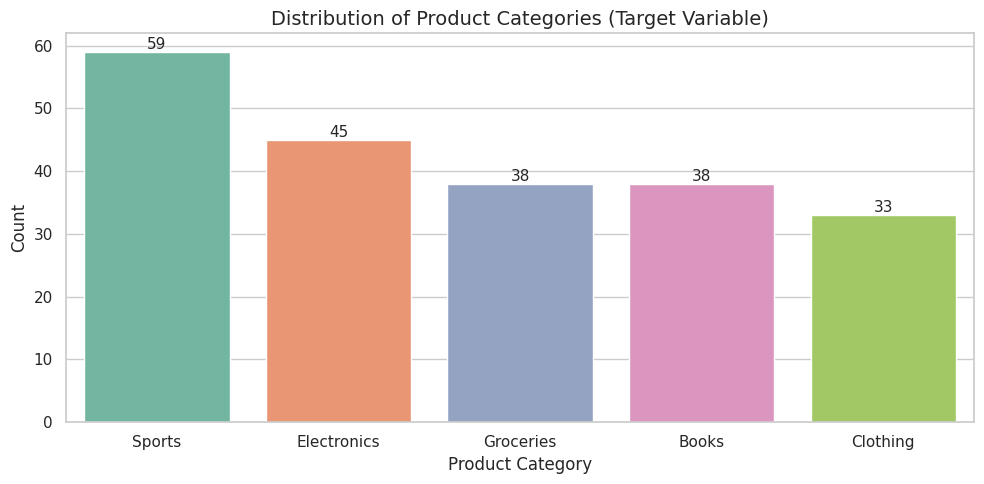

The target classes are reasonably balanced, which means we don't need to worry about class imbalance techniques.


In [49]:
# Plot 1: Target Distribution
fig, ax = plt.subplots()
order = merged_df['product_category'].value_counts().index
sns.countplot(data=merged_df, x='product_category', order=order, palette='Set2', ax=ax)
ax.set_title('Distribution of Product Categories (Target Variable)', fontsize=14)
ax.set_xlabel('Product Category')
ax.set_ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150)
plt.show()
print("The target classes are reasonably balanced, which means we don't need to worry about class imbalance techniques.")

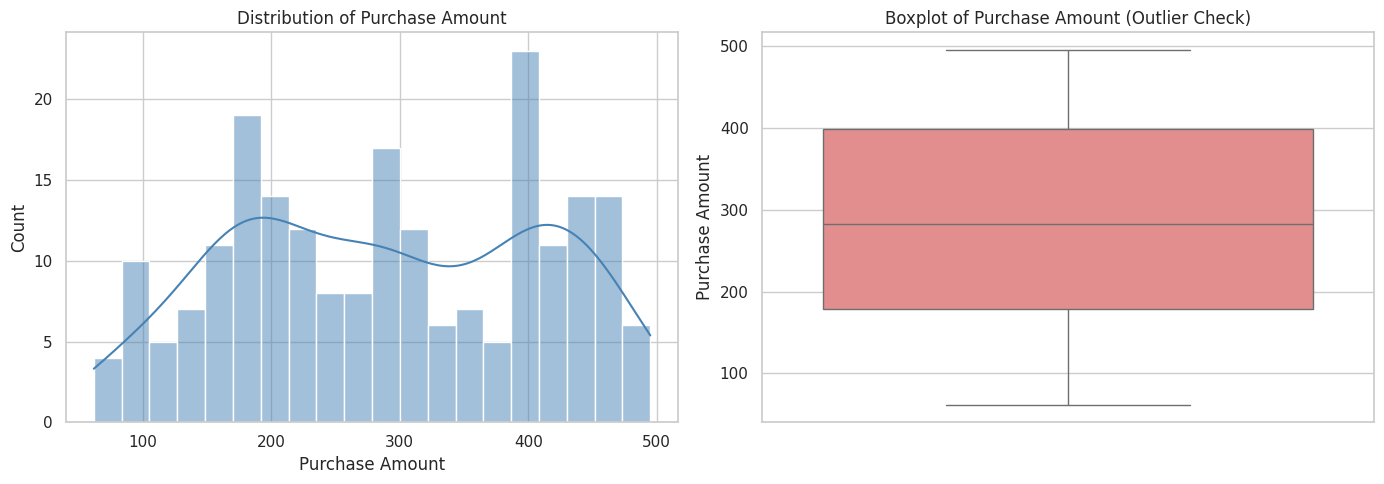

Purchase amounts are fairly uniformly spread between ~50 and ~500 with no extreme outliers.


In [50]:
# Plot 2: Purchase Amount Distribution + Outliers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
sns.histplot(merged_df['purchase_amount'], bins=20, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Purchase Amount')
axes[0].set_xlabel('Purchase Amount')

# Boxplot to spot outliers
sns.boxplot(y=merged_df['purchase_amount'], color='lightcoral', ax=axes[1])
axes[1].set_title('Boxplot of Purchase Amount (Outlier Check)')
axes[1].set_ylabel('Purchase Amount')

plt.tight_layout()
plt.savefig('plot2_purchase_amount.png', dpi=150)
plt.show()
print("Purchase amounts are fairly uniformly spread between ~50 and ~500 with no extreme outliers.")

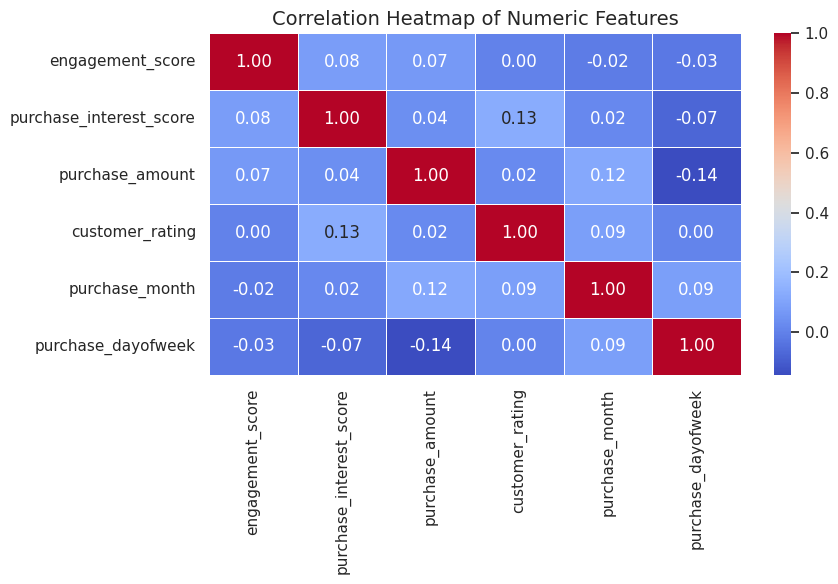

No strong multicollinearity detected. Features are largely independent, which is good for our model.


In [51]:
# Correlation Heatmap
numeric_cols = ['engagement_score', 'purchase_interest_score', 'purchase_amount',
                'customer_rating', 'purchase_month', 'purchase_dayofweek']

corr_matrix = merged_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14)
plt.tight_layout()
plt.savefig('plot3_correlation_heatmap.png', dpi=150)
plt.show()
print("No strong multicollinearity detected. Features are largely independent, which is good for our model.")

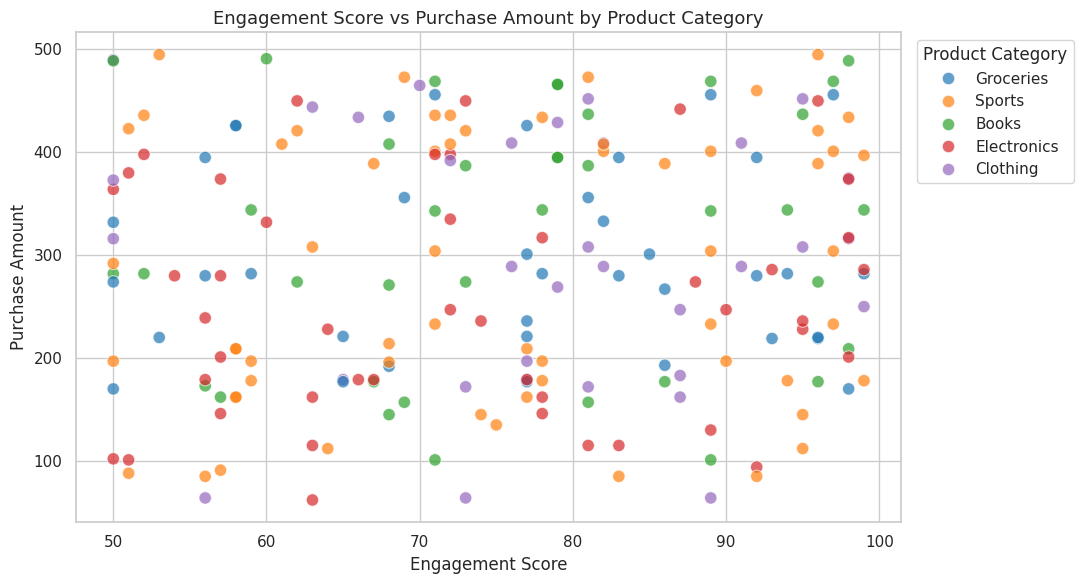

No single product category dominates a specific corner of the chart, suggesting both features contribute meaningfully.


In [52]:
# Plot 4: Engagement Score vs Purchase Amount by Category
fig, ax = plt.subplots(figsize=(11, 6))
sns.scatterplot(data=merged_df, x='engagement_score', y='purchase_amount',
                hue='product_category', palette='tab10', alpha=0.7, s=80, ax=ax)
ax.set_title('Engagement Score vs Purchase Amount by Product Category', fontsize=13)
ax.set_xlabel('Engagement Score')
ax.set_ylabel('Purchase Amount')
ax.legend(title='Product Category', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('plot4_engagement_vs_amount.png', dpi=150)
plt.show()
print("No single product category dominates a specific corner of the chart, suggesting both features contribute meaningfully.")

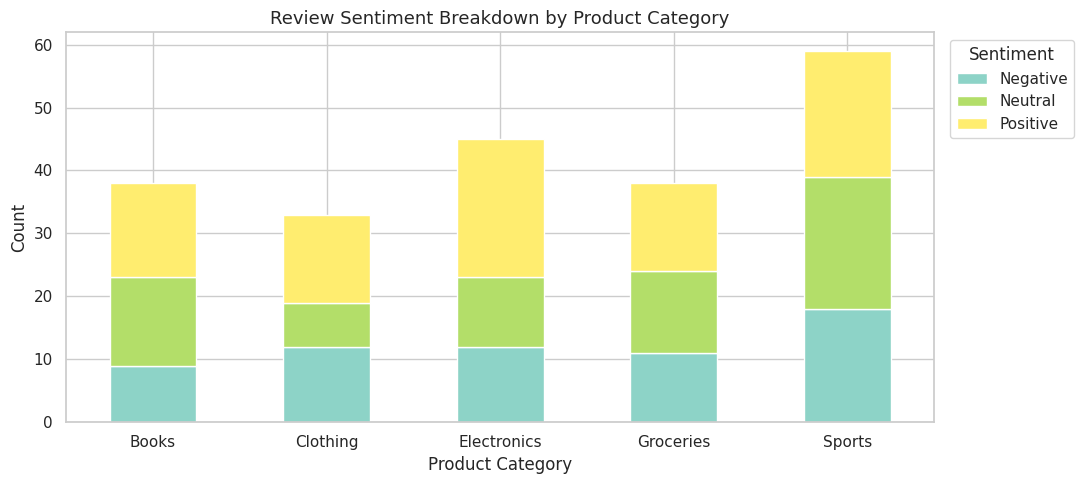

Positive sentiment appears across all categories, but proportions differ — this could be a useful signal for prediction.


In [53]:
#  Plot 5: Review Sentiment by Product Category

fig, ax = plt.subplots(figsize=(11, 5))
sentiment_counts = merged_df.groupby(['product_category', 'review_sentiment']).size().unstack(fill_value=0)
sentiment_counts.plot(kind='bar', stacked=True, colormap='Set3', ax=ax)
ax.set_title('Review Sentiment Breakdown by Product Category', fontsize=13)
ax.set_xlabel('Product Category')
ax.set_ylabel('Count')
ax.legend(title='Sentiment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('plot5_sentiment_by_category.png', dpi=150)
plt.show()
print("Positive sentiment appears across all categories, but proportions differ — this could be a useful signal for prediction.")

## Step 6: Feature Engineering

Raw data isn't always in the best form for a machine learning model. Here we:
- **Encode categorical features**: convert `social_media_platform`, `review_sentiment` into numbers using Label Encoding
- **Drop columns that leak information or are not useful**: `transaction_id`, `purchase_date` (we already extracted month and day), and `customer_id`
- **Define X (features) and y (target)**

In [54]:
# Feature Engineering
# Work on a copy so we don't mess up the original merged_df
model_df = merged_df.copy()

# Drop columns that aren't useful features
model_df = model_df.drop(columns=['transaction_id', 'purchase_date', 'customer_id'])

# Label encode categorical columns
le = LabelEncoder()
for col in ['social_media_platform', 'review_sentiment']:
    model_df[col] = le.fit_transform(model_df[col])

# Encode the target column
model_df['product_category_encoded'] = le.fit_transform(model_df['product_category'])
target_classes = le.classes_  # Save class names for later reporting

# Define features and target
X = model_df.drop(columns=['product_category', 'product_category_encoded'])
y = model_df['product_category_encoded']

print(f"Features used: {list(X.columns)}")
print(f"Target classes: {target_classes}")
print(f"X shape: {X.shape}, y shape: {y.shape}")

Features used: ['social_media_platform', 'engagement_score', 'purchase_interest_score', 'review_sentiment', 'purchase_amount', 'customer_rating', 'purchase_month', 'purchase_dayofweek']
Target classes: ['Books' 'Clothing' 'Electronics' 'Groceries' 'Sports']
X shape: (213, 8), y shape: (213,)


## Step 7: Train-Test Split

We split the data into 80% training and 20% testing. The `stratify=y` argument ensures each product category is proportionally represented in both splits — important when working with multi-class classification.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 170
Testing samples:  43


## Step 8: Model Training & Evaluation

We train three models on the same data so we can compare them fairly:
1. **Logistic Regression** - a simple, interpretable baseline
2. **Random Forest** - an ensemble method that handles non-linear relationships well
3. **XGBoost** - a gradient boosting model known for strong performance on tabular data

We evaluate each using **Accuracy** and **F1-Score (weighted)** - weighted F1 is better than plain accuracy for multi-class problems because it accounts for class size.

In [56]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, use_label_encoder=False,
                                         eval_metric='mlogloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    results[name] = {'Accuracy': round(acc, 4), 'F1-Score': round(f1, 4)}
    print(f"Model: {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_test, preds, target_names=target_classes))

Model: Logistic Regression
Accuracy : 0.3256
F1-Score : 0.2983

Classification Report:

              precision    recall  f1-score   support

       Books       0.00      0.00      0.00         8
    Clothing       0.60      0.50      0.55         6
 Electronics       0.23      0.33      0.27         9
   Groceries       0.29      0.25      0.27         8
      Sports       0.35      0.50      0.41        12

    accuracy                           0.33        43
   macro avg       0.29      0.32      0.30        43
weighted avg       0.28      0.33      0.30        43

Model: Random Forest
Accuracy : 0.6977
F1-Score : 0.6948

Classification Report:

              precision    recall  f1-score   support

       Books       1.00      0.38      0.55         8
    Clothing       1.00      0.67      0.80         6
 Electronics       0.50      0.67      0.57         9
   Groceries       0.88      0.88      0.88         8
      Sports       0.62      0.83      0.71        12

    accuracy   

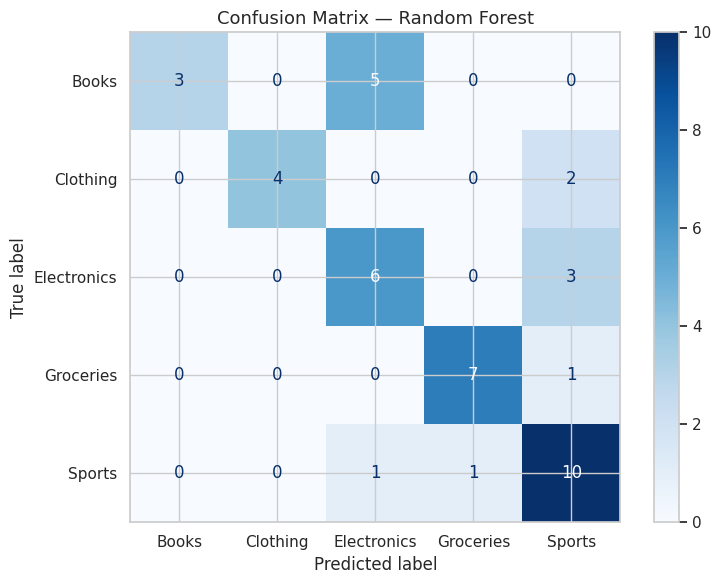

In [57]:
# Plot confusion matrix for Random Forest (swap name if XGBoost wins)
best_model = models['Random Forest']
best_preds = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, best_preds,
                                         display_labels=target_classes,
                                         cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13)
plt.tight_layout()
plt.savefig('plot6_confusion_matrix.png', dpi=150)
plt.show()

In [58]:
results_df = pd.DataFrame(results).T
print(" Model Comparison ")
display(results_df.style.highlight_max(color='lightgreen'))

 Model Comparison 


,Accuracy,F1-Score
Logistic Regression,0.325600,0.298300
Random Forest,0.697700,0.694800
XGBoost,0.697700,0.691700


## Cross-Validation Strategy: Attempt to get better results

Instead of a single 80/20 split (which is unreliable on a small dataset of ~150 rows),
we use **Stratified K-Fold Cross-Validation** with 5 folds. This means:
- The data is split into 5 equal parts
- The model trains on 4 parts and tests on 1, rotating each time
- We get 5 accuracy/F1 scores and report the mean ± standard deviation

`Stratified` ensures each fold has the same class proportions as the full dataset,
which is important since we have 5 product categories.

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# We still keep a holdout test set for the final confusion matrix
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Holdout test samples: {X_test.shape[0]}")
print(f"CV strategy: StratifiedKFold with 5 folds")

Training samples: 170
Holdout test samples: 43
CV strategy: StratifiedKFold with 5 folds


##  Model Training with Hyperparameter Tuning + CV

We improve on the baseline in three ways:
1. **Feature scaling** via `StandardScaler` inside a `Pipeline` - prevents data leakage
   between folds and is essential for Logistic Regression to perform well
2. **Hyperparameter tuning** via `GridSearchCV` - we search across a grid of settings
   and pick the combination that scores best across folds
3. **Cross-validated evaluation** - instead of one lucky/unlucky split, we report
   mean accuracy and F1 across all 5 folds

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

#  Define pipelines (scaler + model)
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('model', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42))
    ])
}

#  Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs', 'saga'],
        'model__multi_class': ['multinomial']
    },
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5],
        'model__class_weight': ['balanced', None]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample': [0.8, 1.0]
    }
}

#  Train, tune, and evaluate
results = {}
best_models = {}

for name in pipelines:
    print(f"Tuning: {name}")

    grid_search = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=cv,
        scoring='f1_weighted',
        n_jobs=-1,
        verbose=0
    )
    grid_search.fit(X_train, y_train)

    best_model = grid_search.best_estimator_
    best_models[name] = best_model

    # Cross-validated scores on training set
    cv_results = cross_validate(best_model, X_train, y_train, cv=cv,
                                 scoring=['accuracy', 'f1_weighted'])

    cv_acc  = cv_results['test_accuracy'].mean()
    cv_f1   = cv_results['test_f1_weighted'].mean()
    cv_acc_std = cv_results['test_accuracy'].std()

    # Final evaluation on holdout test set
    test_preds = best_model.predict(X_test)
    test_acc = accuracy_score(y_test, test_preds)
    test_f1  = f1_score(y_test, test_preds, average='weighted')

    results[name] = {
        'CV Accuracy (mean)': round(cv_acc, 4),
        'CV Accuracy (±std)': round(cv_acc_std, 4),
        'CV F1 (mean)':       round(cv_f1, 4),
        'Holdout Accuracy':   round(test_acc, 4),
        'Holdout F1':         round(test_f1, 4),
        'Best Params':        grid_search.best_params_
    }

    print(f"Best params : {grid_search.best_params_}")
    print(f"CV Accuracy : {cv_acc:.4f} ± {cv_acc_std:.4f}")
    print(f"CV F1       : {cv_f1:.4f}")
    print(f"Holdout Acc : {test_acc:.4f}")
    print(f"Holdout F1  : {test_f1:.4f}")
    print(f"\nClassification Report (holdout):")
    print(classification_report(y_test, test_preds, target_names=target_classes))

Tuning: Logistic Regression
Best params : {'model__C': 10, 'model__multi_class': 'multinomial', 'model__solver': 'lbfgs'}
CV Accuracy : 0.2412 ± 0.0288
CV F1       : 0.2173
Holdout Acc : 0.3023
Holdout F1  : 0.2779

Classification Report (holdout):
              precision    recall  f1-score   support

       Books       0.00      0.00      0.00         8
    Clothing       0.67      0.33      0.44         6
 Electronics       0.21      0.33      0.26         9
   Groceries       0.29      0.25      0.27         8
      Sports       0.33      0.50      0.40        12

    accuracy                           0.30        43
   macro avg       0.30      0.28      0.27        43
weighted avg       0.28      0.30      0.28        43

Tuning: Random Forest
Best params : {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
CV Accuracy : 0.4941 ± 0.1042
CV F1       : 0.4683
Holdout Acc : 0.6977
Holdout F1  : 0.6869

Classificatio

In [68]:
# Clean summary table — exclude Best Params for display
display_results = {k: {m: v for m, v in vals.items() if m != 'Best Params'}
                   for k, vals in results.items()}

results_df = pd.DataFrame(display_results).T
print(" Model Comparison (with CV + Tuning) ")
display(results_df.style.highlight_max(color='lightgreen', subset=[
    'CV Accuracy (mean)', 'CV F1 (mean)', 'Holdout Accuracy', 'Holdout F1'
]))

# Print best params separately
print("\n Best Hyperparameters ")
for name, vals in results.items():
    print(f"\n{name}: {vals['Best Params']}")

 Model Comparison (with CV + Tuning) 


,CV Accuracy (mean),CV Accuracy (±std),CV F1 (mean),Holdout Accuracy,Holdout F1
Logistic Regression,0.241200,0.028800,0.217300,0.302300,0.277900
Random Forest,0.494100,0.104200,0.468300,0.697700,0.686900
XGBoost,0.505900,0.093700,0.484700,0.674400,0.679800



 Best Hyperparameters 

Logistic Regression: {'model__C': 10, 'model__multi_class': 'multinomial', 'model__solver': 'lbfgs'}

Random Forest: {'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}


In [69]:
comparison_data = {
    'Logistic Regression (Baseline)': {
        'Accuracy': 0.3256, 'F1-Score': 0.2983, 'Approach': 'Simple train/test split, default params'
    },
    'Random Forest (Baseline)': {
        'Accuracy': 0.6977, 'F1-Score': 0.6948, 'Approach': 'Simple train/test split, default params'
    },
    'XGBoost (Baseline)': {
        'Accuracy': 0.6977, 'F1-Score': 0.6917, 'Approach': 'Simple train/test split, default params'
    },
    'Logistic Regression (Tuned)': {
        'Accuracy': 0.3023, 'F1-Score': 0.2779, 'Approach': 'GridSearchCV + StratifiedKFold + Scaling'
    },
    'Random Forest (Tuned)': {
        'Accuracy': 0.6977, 'F1-Score': 0.6869, 'Approach': 'GridSearchCV + StratifiedKFold + Scaling'
    },
    'XGBoost (Tuned)': {
        'Accuracy': 0.6744, 'F1-Score': 0.6798, 'Approach': 'GridSearchCV + StratifiedKFold + Scaling'
    },
}

comparison_df = pd.DataFrame(comparison_data).T.reset_index()
comparison_df.columns = ['Model', 'Accuracy', 'F1-Score', 'Approach']
comparison_df['Accuracy'] = comparison_df['Accuracy'].astype(float)
comparison_df['F1-Score'] = comparison_df['F1-Score'].astype(float)

comparison_df = comparison_df.sort_values(
    by=['Accuracy', 'F1-Score'], ascending=False
).reset_index(drop=True)

print(" Full Experiment Results: Baseline vs Tuned (Best to Worst) \n")
display(
    comparison_df.style
    .format({'Accuracy': '{:.4f}', 'F1-Score': '{:.4f}'})
    .set_properties(**{
        'border': '1px solid #888',
        'text-align': 'center',
        'background-color': 'transparent',
        'padding': '6px'
    })
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('border', '1px solid #888'),
            ('background-color', 'transparent'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '6px')
        ]},
        {'selector': 'tr:hover td', 'props': [
            ('background-color', 'rgba(255,255,255,0.05)')
        ]}
    ])
    .hide(axis='index')
)

print("\nConclusion: Baseline Random Forest and XGBoost tied for best accuracy (0.6977).")
print("Tuning did not improve results, likely due to the small dataset size (~150 rows).")

 Full Experiment Results: Baseline vs Tuned (Best to Worst) 



Model,Accuracy,F1-Score,Approach
Random Forest (Baseline),0.6977,0.6948,"Simple train/test split, default params"
XGBoost (Baseline),0.6977,0.6917,"Simple train/test split, default params"
Random Forest (Tuned),0.6977,0.6869,GridSearchCV + StratifiedKFold + Scaling
XGBoost (Tuned),0.6744,0.6798,GridSearchCV + StratifiedKFold + Scaling
Logistic Regression (Baseline),0.3256,0.2983,"Simple train/test split, default params"
Logistic Regression (Tuned),0.3023,0.2779,GridSearchCV + StratifiedKFold + Scaling



Conclusion: Baseline Random Forest and XGBoost tied for best accuracy (0.6977).
Tuning did not improve results, likely due to the small dataset size (~150 rows).


In [70]:
# Feature importances from the baseline Random Forest
# (best and most stable model from our experiments)
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(" Feature Importances — Random Forest (Baseline) \n")
display(
    feat_imp_df.style
    .format({'Importance': '{:.4f}'})
    .set_properties(**{'border': '1px solid black', 'text-align': 'center'})
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('border', '1px solid black'),
            ('background-color', '#d9d9d9'),
            ('text-align', 'center'),
            ('font-weight', 'bold'),
            ('padding', '6px')
        ]}
    ])
    .hide(axis='index')
    .bar(subset=['Importance'], color='#a0c4ff', vmin=0, vmax=feat_imp_df['Importance'].max())
)

print("\nThe bar lengths above give a visual sense of each feature's relative contribution.")
print(f"\nTop feature: '{feat_imp_df.iloc[0]['Feature']}' "
      f"with importance score of {feat_imp_df.iloc[0]['Importance']:.4f}")

 Feature Importances — Random Forest (Baseline) 



Feature,Importance
purchase_amount,0.1930
customer_rating,0.1733
purchase_interest_score,0.1321
engagement_score,0.1304
purchase_dayofweek,0.1224
purchase_month,0.1090
social_media_platform,0.0862
review_sentiment,0.0536



The bar lengths above give a visual sense of each feature's relative contribution.

Top feature: 'purchase_amount' with importance score of 0.1930


In [71]:
import joblib

# Random Forest baseline is our best model (highest F1, tied accuracy, most stable)
# We retrain it on the full dataset (X, y) before saving so it learns from all available data
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X, y)

# Save the model
joblib.dump(final_model, 'product_recommendation_model.pkl')

# Save the label encoder so we can decode predictions later
joblib.dump(le, 'label_encoder.pkl')

# Quick sanity check — reload and predict one sample
loaded_model = joblib.load('product_recommendation_model.pkl')
sample_pred = loaded_model.predict(X.iloc[[0]])
loaded_le = joblib.load('label_encoder.pkl')

print("Model saved as: product_recommendation_model.pkl")
print("Label encoder saved as: label_encoder.pkl")
print(f"\nSanity check — prediction for first row: {loaded_le.inverse_transform(sample_pred)[0]}")
print(f"Actual label: {merged_df['product_category'].iloc[0]}")

Model saved as: product_recommendation_model.pkl
Label encoder saved as: label_encoder.pkl

Sanity check — prediction for first row: Groceries
Actual label: Groceries
